In [5]:
# Install kagglehub
!pip install -q kagglehub

import kagglehub

# Download DEAP dataset
path = kagglehub.dataset_download("manh123df/deap-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deap-dataset' dataset.
Path to dataset files: /kaggle/input/deap-dataset


In [6]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import spectrogram
from scipy.signal import welch

import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

In [9]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    for f in files[:10]:
        print("   ", f)

/kaggle/input/deap-dataset
/kaggle/input/deap-dataset/deap-dataset
    EDA_DEAP.ipynb
/kaggle/input/deap-dataset/deap-dataset/data_preprocessed_python
    s20.dat
    s17.dat
    s31.dat
    s14.dat
    s32.dat
    s28.dat
    s24.dat
    s18.dat
    s22.dat
    s02.dat
/kaggle/input/deap-dataset/deap-dataset/Metadata
    video_list_fixed.xlsx
    online_ratings.xls
    participant_questionnaire.xls
    video_list.xlsx
    participant_ratings.xls
/kaggle/input/deap-dataset/deap-dataset/audio_stimuli_MIDI
    exp_id_18.mid
    exp_id_27.mid
    exp_id_28.mid
    exp_id_30.mid
    exp_id_15.mid
    exp_id_40.mid
    exp_id_2.mid
    exp_id_3.mid
    exp_id_24.mid
    exp_id_14.mid
/kaggle/input/deap-dataset/deap-dataset/metadata_xls
    online_ratings.xls
    participant_questionnaire.xls
    participant_ratings.xls
    video_list.xls
/kaggle/input/deap-dataset/deap-dataset/audio_stimuli_MIDI_tempo24
    exp_id_26_tempo24.mid
    exp_id_39_tempo24.mid
    exp_id_6_tempo24.mid
    exp_id_

In [10]:
import pickle

file_path = "/kaggle/input/deap-dataset/deap-dataset/data_preprocessed_python/s01.dat"

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

X = data["data"]
labels = data["labels"]

print("EEG Shape:", X.shape)
print("Labels Shape:", labels.shape)

EEG Shape: (40, 40, 8064)
Labels Shape: (40, 4)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import spectrogram
from scipy.signal import welch

In [15]:
eeg_channels = [
    'Fp1','AF3','F3','F7','FC5','FC1','C3','T7',
    'CP5','CP1','P3','P7','PO3','O1','Oz','Pz',
    'Fp2','AF4','F4','F8','FC6','FC2','C4','T8',
    'CP6','CP2','P4','P8','PO4','O2','HEOG','VEOG'
]

In [16]:
regions = {
    'Frontal': 'F3',
    'Central': 'C3',
    'Temporal': 'T7',
    'Parietal': 'P3',
    'Occipital': 'O1'
}

In [17]:
trial = np.argmax(labels[:,1])

print("Selected Trial:", trial)
print("Valence:", labels[trial][0])
print("Arousal:", labels[trial][1])

Selected Trial: 34
Valence: 2.06
Arousal: 8.15


In [18]:
signals = {}

for region, channel in regions.items():
    idx = eeg_channels.index(channel)
    signals[region] = X[trial, idx, :]

print("Signals Extracted Successfully")

Signals Extracted Successfully


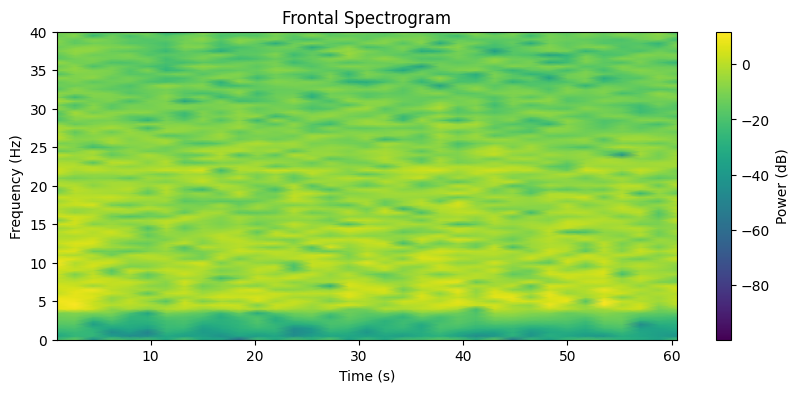

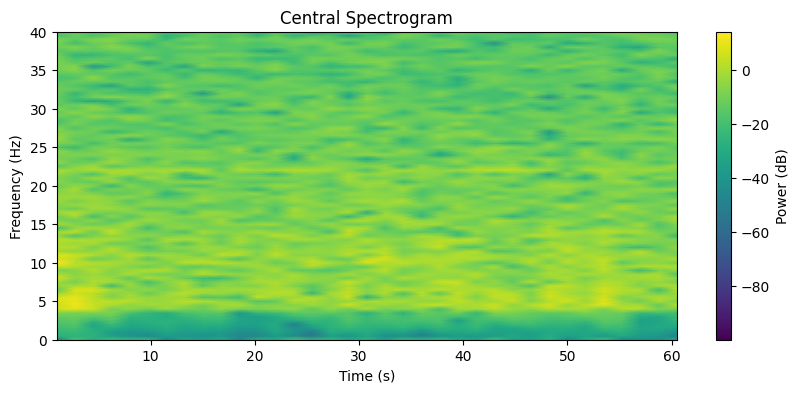

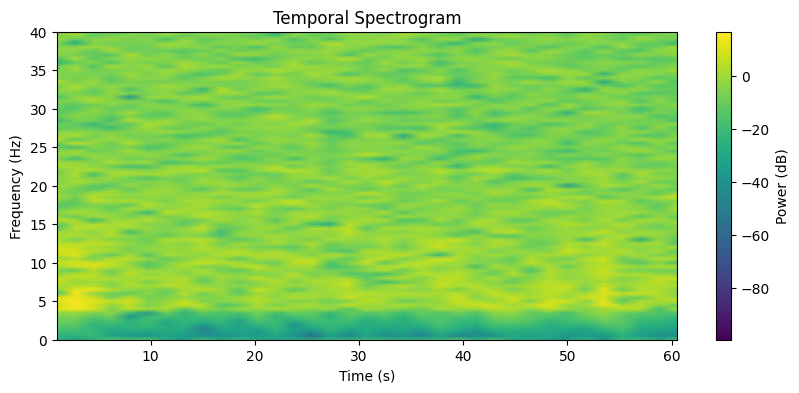

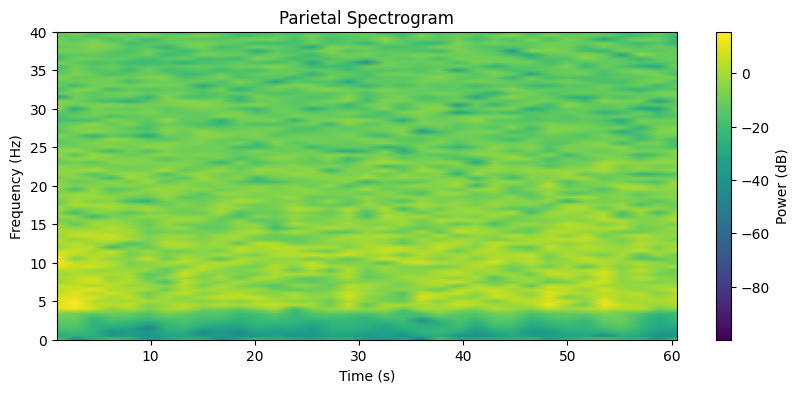

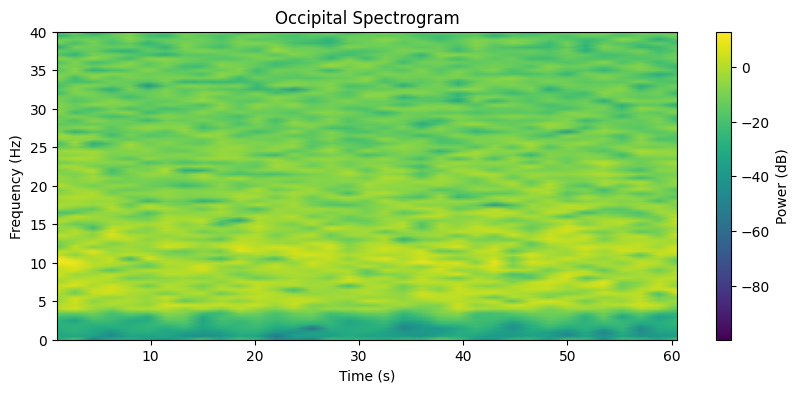

In [19]:
fs = 128

for region, signal in signals.items():

    f, t, Sxx = spectrogram(
        signal,
        fs=fs,
        nperseg=256
    )

    plt.figure(figsize=(10,4))

    plt.pcolormesh(
        t,
        f,
        10*np.log10(Sxx + 1e-10),
        shading='gouraud'
    )

    plt.title(f"{region} Spectrogram")
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.colorbar(label="Power (dB)")
    plt.ylim(0,40)

    plt.show()

In [20]:
bands = {
    'Delta': (0.5,4),
    'Theta': (4,8),
    'Alpha': (8,13),
    'Beta': (13,30)
}

In [21]:
def compute_band_power(signal, fs):

    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=512
    )

    powers = {}

    for band, (low, high) in bands.items():

        idx = np.logical_and(
            freqs >= low,
            freqs <= high
        )

        powers[band] = np.trapz(
            psd[idx],
            freqs[idx]
        )

    return powers

In [22]:
results = []

for region, signal in signals.items():

    bp = compute_band_power(signal, fs)

    results.append([
        region,
        bp['Delta'],
        bp['Theta'],
        bp['Alpha'],
        bp['Beta']
    ])

power_df = pd.DataFrame(
    results,
    columns=[
        'Region',
        'Delta',
        'Theta',
        'Alpha',
        'Beta'
    ]
)

power_df

/tmp/ipykernel_721/665789957.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  powers[band] = np.trapz(


,Region,Delta,Theta,Alpha,Beta
0,Frontal,0.165029,6.874815,4.294157,6.385070
1,Central,0.142094,4.456854,3.082459,3.349914
2,Temporal,0.370859,10.720240,6.535872,9.337966
3,Parietal,0.328896,9.041948,6.201683,5.330681
4,Occipital,0.072554,4.269324,5.946190,4.873054


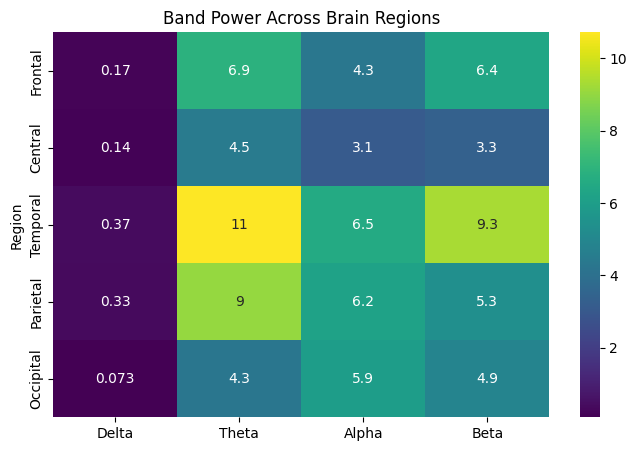

In [23]:
plt.figure(figsize=(8,5))

sns.heatmap(
    power_df.set_index('Region'),
    annot=True,
    cmap='viridis'
)

plt.title("Band Power Across Brain Regions")
plt.show()

In [24]:
dominant_bands = []

for _, row in power_df.iterrows():

    dominant = row[1:].idxmax()

    dominant_bands.append([
        row['Region'],
        dominant
    ])

dominant_df = pd.DataFrame(
    dominant_bands,
    columns=['Region', 'Dominant Band']
)

dominant_df

,Region,Dominant Band
0,Frontal,Theta
1,Central,Theta
2,Temporal,Theta
3,Parietal,Theta
4,Occipital,Alpha


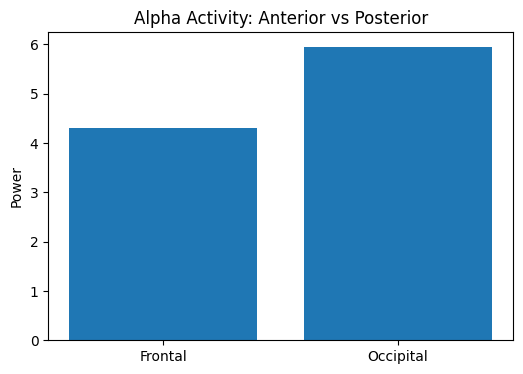

In [25]:
frontal_alpha = power_df[
    power_df['Region']=='Frontal'
]['Alpha'].values[0]

occipital_alpha = power_df[
    power_df['Region']=='Occipital'
]['Alpha'].values[0]

plt.figure(figsize=(6,4))

plt.bar(
    ['Frontal','Occipital'],
    [frontal_alpha, occipital_alpha]
)

plt.title("Alpha Activity: Anterior vs Posterior")
plt.ylabel("Power")

plt.show()

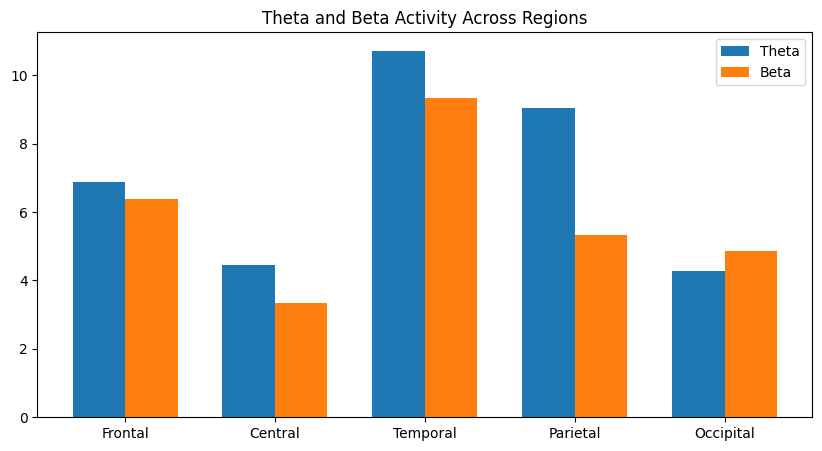

In [26]:
x = np.arange(len(power_df))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    power_df['Theta'],
    width,
    label='Theta'
)

plt.bar(
    x + width/2,
    power_df['Beta'],
    width,
    label='Beta'
)

plt.xticks(
    x,
    power_df['Region']
)

plt.legend()
plt.title("Theta and Beta Activity Across Regions")

plt.show()

In [27]:
signal = signals['Frontal']

n = len(signal)

segments = {
    'Beginning': signal[:n//3],
    'Middle': signal[n//3:2*n//3],
    'End': signal[2*n//3:]
}

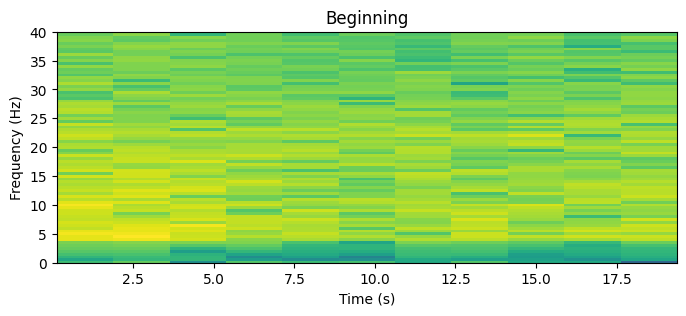

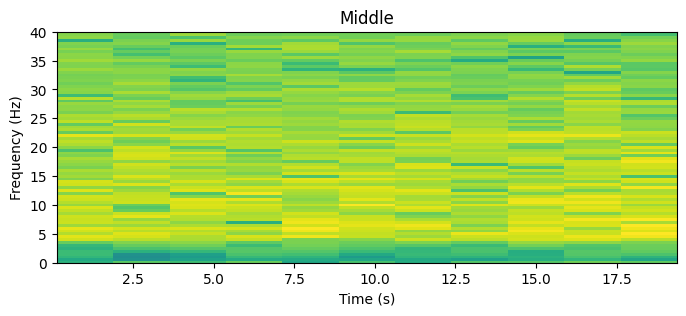

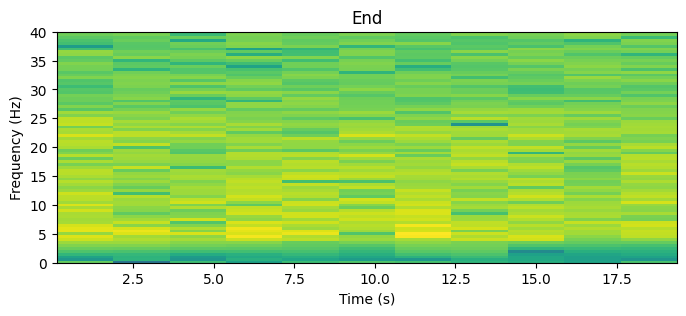

In [28]:
for name, seg in segments.items():

    f, t, Sxx = spectrogram(
        seg,
        fs=128,
        nperseg=256
    )

    plt.figure(figsize=(8,3))

    plt.pcolormesh(
        t,
        f,
        10*np.log10(Sxx + 1e-10)
    )

    plt.title(name)
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.ylim(0,40)

    plt.show()